# Laboratorio 5 — Redes Neuronales Convolucionales (CNN)

## Clasificación de Imágenes con Fashion-MNIST

Este laboratorio tiene como objetivo implementar y analizar diferentes arquitecturas de **Redes Neuronales Convolucionales (CNN)** para la clasificación de imágenes utilizando el dataset **Fashion-MNIST**.

## Objetivos

- Implementar una CNN básica para clasificación de imágenes.
- Aplicar técnicas de regularización para evitar overfitting.
- Utilizar **Data Augmentation** para mejorar la generalización.
- Aplicar **Transfer Learning** con modelos preentrenados.
- Analizar el rendimiento del modelo mediante métricas y visualizaciones.

## Tecnologías utilizadas

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib

Este notebook forma parte de mi portafolio de **Deep Learning aplicado a visión por computador**.

# 1. Configuración del entorno

Para ejecutar este laboratorio se requieren las siguientes librerías:

- TensorFlow
- NumPy
- Matplotlib

Instalación:

```bash
pip install tensorflow numpy matplotlib

In [15]:

# Importación de librerías necesarias

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt

# Verificamos la versión de TensorFlow
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 2. Carga del Dataset

Usaremos el dataset **Fashion-MNIST**, que contiene:

- 60,000 imágenes de entrenamiento
- 10,000 imágenes de prueba
- 10 clases de prendas de vestir

Cada imagen tiene tamaño **28x28 píxeles en escala de grises**.

In [16]:
# Cargamos el dataset Fashion-MNIST desde Keras

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


In [17]:
# Normalización de los datos
# Convertimos los valores de píxeles de rango [0,255] a [0,1]

x_train = x_train / 255.0
x_test = x_test / 255.0

# Las CNN esperan una dimensión de canal
# Expandimos dimensiones para convertir (28,28) -> (28,28,1)

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("New shape:", x_train.shape)

New shape: (60000, 28, 28, 1)


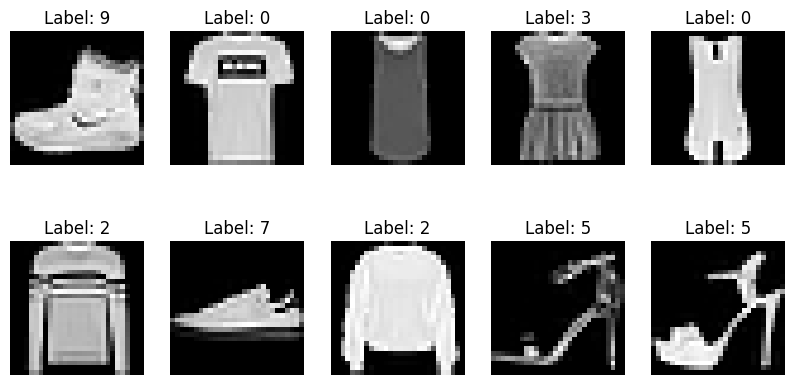

In [18]:
# Visualizamos algunas imágenes del dataset

plt.figure(figsize=(10,5))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    
    plt.title(f"Label: {y_train[i]}")
    
    plt.axis("off")

plt.show()

# Actividad 1 — Construcción de una CNN básica

Las **Redes Neuronales Convolucionales (CNN)** son especialmente eficientes para procesar imágenes.

Una CNN está compuesta por:

- Capas convolucionales → detectan características
- Capas de pooling → reducen dimensionalidad
- Capas densas → realizan clasificación

Arquitectura del modelo:

Conv2D → MaxPooling → Conv2D → MaxPooling → Dense

In [19]:
# Construcción de una CNN básica

model = models.Sequential()

# Primera capa convolucional
model.add(
    layers.Conv2D(
        32,                 # Número de filtros
        (3,3),              # Tamaño del kernel
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Reducción de dimensionalidad
model.add(layers.MaxPooling2D((2,2)))

# Segunda capa convolucional
model.add(
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(layers.MaxPooling2D((2,2)))

# Aplanamos las características para pasarlas a la red densa
model.add(layers.Flatten())

# Capa densa
model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

# Capa de salida (10 clases)
model.add(
    layers.Dense(
        10,
        activation='softmax'
    )
)

model.summary()

/home/jdvalmart/MachineDeepLearning/venv_tf/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Compilamos el modelo

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [21]:
# Entrenamos el modelo

history = model.fit(

    x_train,
    y_train,

    epochs=10,

    validation_data=(x_test, y_test)
)

Epoch 1/10


2026-03-11 15:35:43.664331: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.8332 - loss: 0.4653 - val_accuracy: 0.8758 - val_loss: 0.3471
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.8861 - loss: 0.3128 - val_accuracy: 0.8931 - val_loss: 0.2946
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9031 - loss: 0.2659 - val_accuracy: 0.8837 - val_loss: 0.3022
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9136 - loss: 0.2340 - val_accuracy: 0.9046 - val_loss: 0.2640
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9227 - loss: 0.2090 - val_accuracy: 0.9016 - val_loss: 0.2680
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9303 - loss: 0.1891 - val_accuracy: 0.9097 - val_loss: 0.2593
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9380 - loss: 0.1686 - val_accuracy: 0.9106 - val_loss: 0.2481
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9420 - loss: 0.15

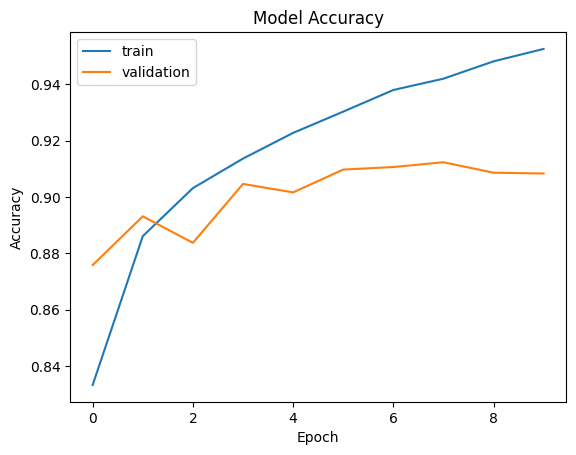

In [22]:
# Visualizamos accuracy durante el entrenamiento

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Actividad 2 — Regularización y Data Augmentation

Los modelos profundos pueden sufrir **overfitting**.

Para evitarlo utilizaremos:

- **Dropout**
- **Batch Normalization**
- **Data Augmentation**

El aumento de datos genera nuevas imágenes modificadas a partir de las originales.

In [23]:
# Generador de aumento de datos

datagen = ImageDataGenerator(

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1
)

datagen.fit(x_train)

# Actividad 3 — Transfer Learning

El **Transfer Learning** permite utilizar redes previamente entrenadas para resolver nuevos problemas.

Usaremos **MobileNetV2** como extractor de características.

In [24]:
base_model = tf.keras.applications.MobileNetV2(

    input_shape=(96,96,3),

    include_top=False,

    weights='imagenet'
)

base_model.trainable = False

In [25]:
# Predicciones del modelo

predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)

errors = np.where(predicted_classes != y_test)[0]

print("Número de errores:", len(errors))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Número de errores: 917


# Conclusiones

Durante este laboratorio se logró:

- Implementar una CNN para clasificación de imágenes.
- Mejorar el modelo usando regularización y aumento de datos.
- Aplicar transferencia de aprendizaje.
- Analizar errores del modelo.

Las CNN siguen siendo una de las arquitecturas más importantes en **visión por computador**.